# 03 - CNN Data Preprocessing

**Cycle Rack Audio Classification Project**

This notebook prepares audio data specifically for Convolutional Neural Network (CNN) training.

## CNN Preprocessing Pipeline:
1. **Mel-Spectrogram Generation**: Convert audio to time-frequency representations
2. **Logarithmic Compression**: Apply log transformation for better dynamic range
3. **Normalization**: Standardize spectrogram values (zero-mean, unit variance)
4. **Data Augmentation**: Generate variations to improve model robustness

## Data Augmentation Techniques:
- Time shifting
- Pitch shifting
- Adding background noise
- Time stretching
- Volume adjustment

In [1]:
# Import required libraries
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Libraries imported successfully!")
print(f"Librosa version: {librosa.__version__}")
print(f"NumPy version: {np.__version__}")

Libraries imported successfully!
Librosa version: 0.11.0
NumPy version: 2.3.4


## Configuration and Path Setup

In [2]:
# Get current working directory and set up paths
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent  # Go up one level to project root

# Define data paths
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
SPECTROGRAMS_DIR = DATA_DIR / "spectrograms"

# Create spectrograms directory
SPECTROGRAMS_DIR.mkdir(parents=True, exist_ok=True)

# Verify paths
print("Path Configuration:")
print(f"  Notebook directory: {NOTEBOOK_DIR}")
print(f"  Project root: {PROJECT_ROOT}")
print(f"  Processed audio: {PROCESSED_DIR}")
print(f"  Spectrograms output: {SPECTROGRAMS_DIR}")
print(f"\nPath checks:")
print(f"  Processed directory exists: {PROCESSED_DIR.exists()}")
print(f"  Spectrograms directory exists: {SPECTROGRAMS_DIR.exists()}")

# Classes
CLASSES = ['background', 'angle_grinder', 'other_power_tools']
CLASS_TO_IDX = {cls: idx for idx, cls in enumerate(CLASSES)}
IDX_TO_CLASS = {idx: cls for cls, idx in CLASS_TO_IDX.items()}

print(f"\nClass mappings:")
for cls, idx in CLASS_TO_IDX.items():
    print(f"  {cls}: {idx}")

# CNN preprocessing configuration
CONFIG = {
    # Audio parameters
    'SAMPLE_RATE': 16000,
    'DURATION': None,  # Use full audio (or set to float for fixed length)
    
    # Mel-spectrogram parameters
    'N_FFT': 2048,
    'HOP_LENGTH': 512,
    'N_MELS': 128,  # Number of mel bands
    'FMIN': 0,  # Minimum frequency
    'FMAX': 8000,  # Maximum frequency (Nyquist for 16kHz)
    
    # Spectrogram size (for CNN input)
    'TARGET_SHAPE': (128, 128),  # (n_mels, time_steps)
    
    # Normalization
    'NORM_METHOD': 'standard',  # 'standard' or 'minmax'
    
    # Data augmentation parameters
    'AUGMENT_TRAIN': True,
    'AUGMENTATION_FACTOR': 3,  # Generate 3 augmented versions per sample
    'TIME_SHIFT_MAX': 0.2,  # Max 20% time shift
    'PITCH_SHIFT_RANGE': (-2, 2),  # Pitch shift in semitones
    'NOISE_FACTOR': 0.005,  # Noise amplitude
    'TIME_STRETCH_RANGE': (0.9, 1.1),  # Speed factor range
    
    # Train/val/test split
    'TEST_SIZE': 0.2,
    'VAL_SIZE': 0.1,  # 10% of remaining after test split
    'RANDOM_STATE': 42
}

print(f"\nCNN Preprocessing Configuration:")
for key, value in CONFIG.items():
    print(f"  {key}: {value}")

Path Configuration:
  Notebook directory: /workspaces/BikeAIv2/notebooks
  Project root: /workspaces/BikeAIv2
  Processed audio: /workspaces/BikeAIv2/data/processed
  Spectrograms output: /workspaces/BikeAIv2/data/spectrograms

Path checks:
  Processed directory exists: True
  Spectrograms directory exists: True

Class mappings:
  background: 0
  angle_grinder: 1
  other_power_tools: 2

CNN Preprocessing Configuration:
  SAMPLE_RATE: 16000
  DURATION: None
  N_FFT: 2048
  HOP_LENGTH: 512
  N_MELS: 128
  FMIN: 0
  FMAX: 8000
  TARGET_SHAPE: (128, 128)
  NORM_METHOD: standard
  AUGMENT_TRAIN: True
  AUGMENTATION_FACTOR: 3
  TIME_SHIFT_MAX: 0.2
  PITCH_SHIFT_RANGE: (-2, 2)
  NOISE_FACTOR: 0.005
  TIME_STRETCH_RANGE: (0.9, 1.1)
  TEST_SIZE: 0.2
  VAL_SIZE: 0.1
  RANDOM_STATE: 42


## Mel-Spectrogram Generation Functions

In [3]:
def generate_mel_spectrogram(y, sr, config):
    """
    Generate mel-spectrogram from audio time series.
    
    Args:
        y (np.array): Audio time series
        sr (int): Sample rate
        config (dict): Configuration parameters
    
    Returns:
        np.array: Mel-spectrogram
    """
    # Generate mel-spectrogram
    mel_spec = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=config['N_FFT'],
        hop_length=config['HOP_LENGTH'],
        n_mels=config['N_MELS'],
        fmin=config['FMIN'],
        fmax=config['FMAX']
    )
    
    return mel_spec


def apply_log_compression(mel_spec, ref=np.max):
    """
    Apply logarithmic compression to mel-spectrogram.
    Converts to decibel scale.
    
    Args:
        mel_spec (np.array): Mel-spectrogram
        ref: Reference value for dB conversion
    
    Returns:
        np.array: Log-compressed mel-spectrogram (in dB)
    """
    log_mel_spec = librosa.power_to_db(mel_spec, ref=ref)
    return log_mel_spec


def resize_spectrogram(spec, target_shape):
    """
    Resize spectrogram to target shape for CNN input.
    
    Args:
        spec (np.array): Spectrogram
        target_shape (tuple): Target (height, width)
    
    Returns:
        np.array: Resized spectrogram
    """
    from scipy.ndimage import zoom
    
    # Calculate zoom factors
    zoom_factors = (target_shape[0] / spec.shape[0], target_shape[1] / spec.shape[1])
    
    # Resize using zoom
    resized_spec = zoom(spec, zoom_factors, order=1)  # Bilinear interpolation
    
    return resized_spec


def normalize_spectrogram(spec, method='standard', mean=None, std=None, min_val=None, max_val=None):
    """
    Normalize spectrogram.
    
    Args:
        spec (np.array): Spectrogram
        method (str): 'standard' (zero-mean, unit variance) or 'minmax' (0-1 range)
        mean, std, min_val, max_val: Pre-computed statistics (optional)
    
    Returns:
        np.array: Normalized spectrogram
        dict: Statistics used for normalization
    """
    if method == 'standard':
        if mean is None or std is None:
            mean = np.mean(spec)
            std = np.std(spec)
        
        normalized = (spec - mean) / (std + 1e-8)
        stats = {'mean': mean, 'std': std}
    
    elif method == 'minmax':
        if min_val is None or max_val is None:
            min_val = np.min(spec)
            max_val = np.max(spec)
        
        normalized = (spec - min_val) / (max_val - min_val + 1e-8)
        stats = {'min': min_val, 'max': max_val}
    
    else:
        raise ValueError(f"Unknown normalization method: {method}")
    
    return normalized, stats


def process_audio_to_spectrogram(audio_path, config, norm_stats=None):
    """
    Complete pipeline: audio -> mel-spectrogram -> log compression -> resize -> normalize.
    
    Args:
        audio_path (Path): Path to audio file
        config (dict): Configuration parameters
        norm_stats (dict): Pre-computed normalization statistics
    
    Returns:
        np.array: Processed spectrogram
        dict: Normalization statistics
    """
    # Load audio
    y, sr = librosa.load(audio_path, sr=config['SAMPLE_RATE'], duration=config['DURATION'])
    
    # Generate mel-spectrogram
    mel_spec = generate_mel_spectrogram(y, sr, config)
    
    # Apply log compression
    log_mel_spec = apply_log_compression(mel_spec)
    
    # Resize to target shape
    resized_spec = resize_spectrogram(log_mel_spec, config['TARGET_SHAPE'])
    
    # Normalize
    if norm_stats:
        normalized_spec, _ = normalize_spectrogram(
            resized_spec, 
            method=config['NORM_METHOD'],
            **norm_stats
        )
        stats = norm_stats
    else:
        normalized_spec, stats = normalize_spectrogram(resized_spec, method=config['NORM_METHOD'])
    
    return normalized_spec, stats

print("Mel-spectrogram generation functions defined!")

Mel-spectrogram generation functions defined!


## Data Augmentation Functions

In [4]:
def time_shift_audio(y, sr, shift_max=0.2):
    """
    Shift audio in time (circular shift).
    
    Args:
        y (np.array): Audio time series
        sr (int): Sample rate
        shift_max (float): Maximum shift as fraction of total length
    
    Returns:
        np.array: Time-shifted audio
    """
    shift = int(np.random.uniform(-shift_max, shift_max) * len(y))
    return np.roll(y, shift)


def pitch_shift_audio(y, sr, n_steps_range=(-2, 2)):
    """
    Shift pitch of audio.
    
    Args:
        y (np.array): Audio time series
        sr (int): Sample rate
        n_steps_range (tuple): Range of semitones to shift
    
    Returns:
        np.array: Pitch-shifted audio
    """
    n_steps = np.random.uniform(n_steps_range[0], n_steps_range[1])
    return librosa.effects.pitch_shift(y, sr=sr, n_steps=n_steps)


def add_noise(y, noise_factor=0.005):
    """
    Add random Gaussian noise to audio.
    
    Args:
        y (np.array): Audio time series
        noise_factor (float): Amplitude of noise
    
    Returns:
        np.array: Noisy audio
    """
    noise = np.random.randn(len(y))
    augmented = y + noise_factor * noise
    return augmented


def time_stretch_audio(y, rate_range=(0.9, 1.1)):
    """
    Stretch or compress audio in time.
    
    Args:
        y (np.array): Audio time series
        rate_range (tuple): Range of stretch rates
    
    Returns:
        np.array: Time-stretched audio
    """
    rate = np.random.uniform(rate_range[0], rate_range[1])
    return librosa.effects.time_stretch(y, rate=rate)


def augment_audio(y, sr, config):
    """
    Apply random augmentation to audio.
    
    Args:
        y (np.array): Audio time series
        sr (int): Sample rate
        config (dict): Configuration with augmentation parameters
    
    Returns:
        np.array: Augmented audio
    """
    # Randomly select augmentation techniques
    augmentations = [
        lambda y: time_shift_audio(y, sr, config['TIME_SHIFT_MAX']),
        lambda y: pitch_shift_audio(y, sr, config['PITCH_SHIFT_RANGE']),
        lambda y: add_noise(y, config['NOISE_FACTOR']),
        lambda y: time_stretch_audio(y, config['TIME_STRETCH_RANGE'])
    ]
    
    # Apply 1-2 random augmentations
    n_augmentations = np.random.randint(1, 3)
    selected_augmentations = np.random.choice(augmentations, n_augmentations, replace=False)
    
    augmented_y = y.copy()
    for aug in selected_augmentations:
        augmented_y = aug(augmented_y)
    
    return augmented_y

print("Data augmentation functions defined!")

Data augmentation functions defined!


## Process All Audio Files

In [5]:
def collect_all_audio_paths(processed_dir, classes):
    """
    Collect all audio file paths organized by class.
    
    Returns:
        list: List of tuples (audio_path, class_label, class_idx)
    """
    audio_data = []
    
    for class_name in classes:
        class_dir = processed_dir / class_name
        if not class_dir.exists():
            print(f"⚠ Warning: {class_dir} does not exist")
            continue
        
        audio_files = list(class_dir.glob("*.wav"))
        class_idx = CLASS_TO_IDX[class_name]
        
        for audio_path in audio_files:
            audio_data.append((audio_path, class_name, class_idx))
        
        print(f"Found {len(audio_files)} files in {class_name}")
    
    return audio_data


# Collect all audio files
print("Collecting audio files...")
audio_data = collect_all_audio_paths(PROCESSED_DIR, CLASSES)
print(f"\nTotal audio files: {len(audio_data)}")

Found 1346 files in background
Found 30 files in angle_grinder
Found 23 files in other_power_tools

Total audio files: 1399


## Generate Spectrograms (Original Data)

In [6]:
# Generate spectrograms for all original audio files
print("Generating mel-spectrograms for original audio...")

spectrograms = []
labels = []
filenames = []
all_norm_stats = []

for audio_path, class_name, class_idx in tqdm(audio_data, desc="Processing original audio"):
    try:
        spec, norm_stats = process_audio_to_spectrogram(audio_path, CONFIG)
        spectrograms.append(spec)
        labels.append(class_idx)
        filenames.append(audio_path.name)
        all_norm_stats.append(norm_stats)
    except Exception as e:
        print(f"Error processing {audio_path.name}: {e}")

# Convert to numpy arrays
spectrograms = np.array(spectrograms)
labels = np.array(labels)

print(f"\nOriginal dataset:")
print(f"  Spectrograms shape: {spectrograms.shape}")
print(f"  Labels shape: {labels.shape}")
print(f"  Unique labels: {np.unique(labels, return_counts=True)}")

Generating mel-spectrograms for original audio...


Processing original audio: 100%|██████████| 1399/1399 [00:10<00:00, 129.63it/s]


Original dataset:
  Spectrograms shape: (1399, 128, 128)
  Labels shape: (1399,)
  Unique labels: (array([0, 1, 2]), array([1346,   30,   23]))


## Apply Data Augmentation

In [7]:
if CONFIG['AUGMENT_TRAIN']:
    print(f"\nApplying data augmentation (factor: {CONFIG['AUGMENTATION_FACTOR']})...")
    
    augmented_spectrograms = []
    augmented_labels = []
    augmented_filenames = []
    
    # Focus augmentation on minority class (angle_grinder)
    minority_class_idx = CLASS_TO_IDX['angle_grinder']
    
    for audio_path, class_name, class_idx in tqdm(audio_data, desc="Augmenting audio"):
        try:
            # Load audio
            y, sr = librosa.load(audio_path, sr=CONFIG['SAMPLE_RATE'], duration=CONFIG['DURATION'])
            
            # Determine number of augmentations
            if class_idx == minority_class_idx:
                n_augmentations = CONFIG['AUGMENTATION_FACTOR'] * 3  # More for minority class
            else:
                n_augmentations = CONFIG['AUGMENTATION_FACTOR']
            
            # Generate augmented versions
            for i in range(n_augmentations):
                # Apply augmentation
                y_aug = augment_audio(y, sr, CONFIG)
                
                # Generate mel-spectrogram
                mel_spec = generate_mel_spectrogram(y_aug, sr, CONFIG)
                log_mel_spec = apply_log_compression(mel_spec)
                resized_spec = resize_spectrogram(log_mel_spec, CONFIG['TARGET_SHAPE'])
                
                # Use mean normalization stats from original data
                mean_stats = {
                    'mean': np.mean([s['mean'] for s in all_norm_stats]),
                    'std': np.mean([s['std'] for s in all_norm_stats])
                } if CONFIG['NORM_METHOD'] == 'standard' else {
                    'min': np.min([s['min'] for s in all_norm_stats]),
                    'max': np.max([s['max'] for s in all_norm_stats])
                }
                
                normalized_spec, _ = normalize_spectrogram(
                    resized_spec,
                    method=CONFIG['NORM_METHOD'],
                    **mean_stats
                )
                
                augmented_spectrograms.append(normalized_spec)
                augmented_labels.append(class_idx)
                augmented_filenames.append(f"{audio_path.stem}_aug{i}.wav")
                
        except Exception as e:
            print(f"Error augmenting {audio_path.name}: {e}")
    
    # Convert to numpy arrays
    augmented_spectrograms = np.array(augmented_spectrograms)
    augmented_labels = np.array(augmented_labels)
    
    print(f"\nAugmented dataset:")
    print(f"  Spectrograms shape: {augmented_spectrograms.shape}")
    print(f"  Labels shape: {augmented_labels.shape}")
    print(f"  Unique labels: {np.unique(augmented_labels, return_counts=True)}")
    
    # Combine original and augmented data
    all_spectrograms = np.concatenate([spectrograms, augmented_spectrograms])
    all_labels = np.concatenate([labels, augmented_labels])
    all_filenames = filenames + augmented_filenames
    
    print(f"\nCombined dataset:")
    print(f"  Total spectrograms: {all_spectrograms.shape}")
    print(f"  Total labels: {all_labels.shape}")
    print(f"  Class distribution: {np.unique(all_labels, return_counts=True)}")
else:
    all_spectrograms = spectrograms
    all_labels = labels
    all_filenames = filenames
    print("Skipping data augmentation")


Applying data augmentation (factor: 3)...


Augmenting audio: 100%|██████████| 1399/1399 [01:28<00:00, 15.79it/s]



Augmented dataset:
  Spectrograms shape: (4377, 128, 128)
  Labels shape: (4377,)
  Unique labels: (array([0, 1, 2]), array([4038,  270,   69]))

Combined dataset:
  Total spectrograms: (5776, 128, 128)
  Total labels: (5776,)
  Class distribution: (array([0, 1, 2]), array([5384,  300,   92]))


## Train/Validation/Test Split

In [8]:
# Add channel dimension for CNN (grayscale image)
all_spectrograms = all_spectrograms[..., np.newaxis]
print(f"Spectrograms shape with channel dimension: {all_spectrograms.shape}")

# First split: separate test set
X_temp, X_test, y_temp, y_test = train_test_split(
    all_spectrograms,
    all_labels,
    test_size=CONFIG['TEST_SIZE'],
    random_state=CONFIG['RANDOM_STATE'],
    stratify=all_labels
)

# Second split: separate validation set from remaining data
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=CONFIG['VAL_SIZE'],
    random_state=CONFIG['RANDOM_STATE'],
    stratify=y_temp
)

print(f"\n{'='*60}")
print("TRAIN/VAL/TEST SPLIT")
print(f"{'='*60}")
print(f"Training set: {X_train.shape} - {len(y_train)} samples")
print(f"  Class distribution: {np.unique(y_train, return_counts=True)}")
print(f"\nValidation set: {X_val.shape} - {len(y_val)} samples")
print(f"  Class distribution: {np.unique(y_val, return_counts=True)}")
print(f"\nTest set: {X_test.shape} - {len(y_test)} samples")
print(f"  Class distribution: {np.unique(y_test, return_counts=True)}")

Spectrograms shape with channel dimension: (5776, 128, 128, 1)

TRAIN/VAL/TEST SPLIT
Training set: (4158, 128, 128, 1) - 4158 samples
  Class distribution: (array([0, 1, 2]), array([3875,  216,   67]))

Validation set: (462, 128, 128, 1) - 462 samples
  Class distribution: (array([0, 1, 2]), array([431,  24,   7]))

Test set: (1156, 128, 128, 1) - 1156 samples
  Class distribution: (array([0, 1, 2]), array([1078,   60,   18]))


## Save Processed Data

In [9]:
# Save train/val/test splits
np.save(SPECTROGRAMS_DIR / 'X_train.npy', X_train)
np.save(SPECTROGRAMS_DIR / 'y_train.npy', y_train)
np.save(SPECTROGRAMS_DIR / 'X_val.npy', X_val)
np.save(SPECTROGRAMS_DIR / 'y_val.npy', y_val)
np.save(SPECTROGRAMS_DIR / 'X_test.npy', X_test)
np.save(SPECTROGRAMS_DIR / 'y_test.npy', y_test)

print("✓ Train/val/test arrays saved")

# Save class mappings
class_info = {
    'class_to_idx': CLASS_TO_IDX,
    'idx_to_class': IDX_TO_CLASS,
    'classes': CLASSES
}
with open(SPECTROGRAMS_DIR / 'class_mappings.json', 'w') as f:
    json.dump(class_info, f, indent=2)

print("✓ Class mappings saved")

# Save configuration
with open(SPECTROGRAMS_DIR / 'cnn_preprocessing_config.json', 'w') as f:
    json.dump(CONFIG, f, indent=2)

print("✓ Configuration saved")

# Save normalization statistics - FIXED VERSION
norm_stats_global = {
    'mean': np.mean([s['mean'] for s in all_norm_stats]) if CONFIG['NORM_METHOD'] == 'standard' else None,
    'std': np.mean([s['std'] for s in all_norm_stats]) if CONFIG['NORM_METHOD'] == 'standard' else None,
    'min': np.min([s['min'] for s in all_norm_stats]) if CONFIG['NORM_METHOD'] == 'minmax' else None,
    'max': np.max([s['max'] for s in all_norm_stats]) if CONFIG['NORM_METHOD'] == 'minmax' else None,
    'method': CONFIG['NORM_METHOD']
}

# Convert numeric values to float, keep method as string
norm_stats_to_save = {}
for k, v in norm_stats_global.items():
    if k == 'method':
        norm_stats_to_save[k] = v  # Keep as string
    else:
        norm_stats_to_save[k] = float(v) if v is not None else None

with open(SPECTROGRAMS_DIR / 'normalization_stats.json', 'w') as f:
    json.dump(norm_stats_to_save, f, indent=2)

print("✓ Normalization statistics saved")


✓ Train/val/test arrays saved
✓ Class mappings saved
✓ Configuration saved
✓ Normalization statistics saved


## Visualization

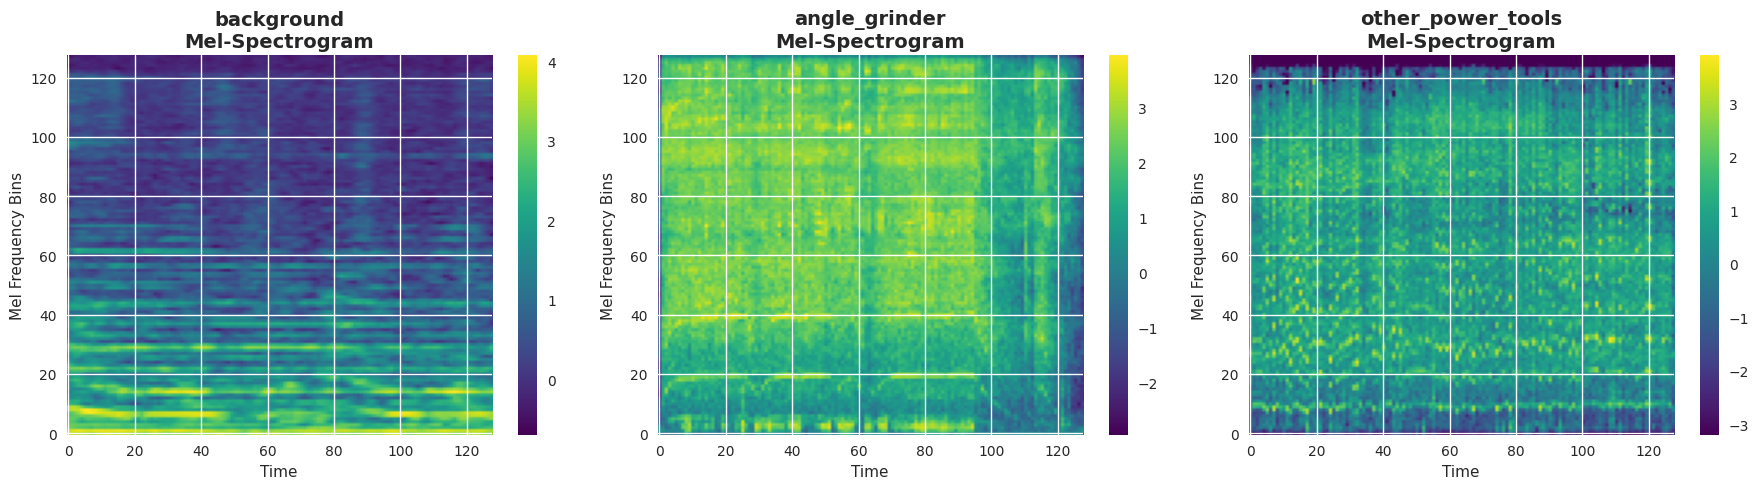

✓ Sample spectrograms visualization saved


In [10]:
# Visualize sample spectrograms from each class
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, class_name in enumerate(CLASSES):
    # Find first sample from this class in training set
    class_idx_val = CLASS_TO_IDX[class_name]
    sample_indices = np.where(y_train == class_idx_val)[0]
    
    if len(sample_indices) > 0:
        sample_spec = X_train[sample_indices[0], :, :, 0]  # Remove channel dimension
        
        im = axes[idx].imshow(sample_spec, aspect='auto', origin='lower', cmap='viridis')
        axes[idx].set_title(f'{class_name}\nMel-Spectrogram', fontsize=14, fontweight='bold')
        axes[idx].set_xlabel('Time')
        axes[idx].set_ylabel('Mel Frequency Bins')
        plt.colorbar(im, ax=axes[idx])

plt.tight_layout()
plt.savefig(SPECTROGRAMS_DIR / 'sample_spectrograms.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Sample spectrograms visualization saved")

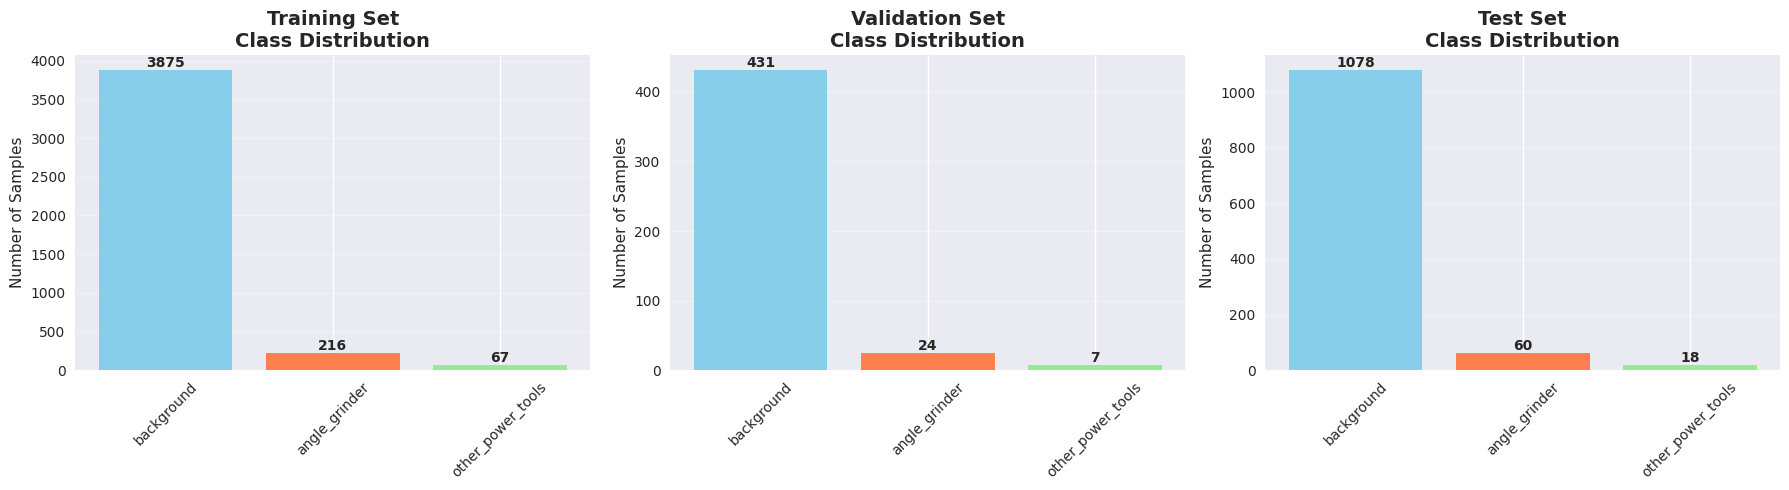

✓ Class distribution visualization saved


In [11]:
# Class distribution across splits
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

splits = [('Training', y_train), ('Validation', y_val), ('Test', y_test)]

for idx, (split_name, y_data) in enumerate(splits):
    unique, counts = np.unique(y_data, return_counts=True)
    class_names = [IDX_TO_CLASS[i] for i in unique]
    
    bars = axes[idx].bar(class_names, counts, color=['skyblue', 'coral', 'lightgreen'])
    axes[idx].set_title(f'{split_name} Set\nClass Distribution', fontsize=14, fontweight='bold')
    axes[idx].set_ylabel('Number of Samples')
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for bar in bars:
        height = bar.get_height()
        axes[idx].text(bar.get_x() + bar.get_width()/2., height,
                       f'{int(height)}',
                       ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig(SPECTROGRAMS_DIR / 'class_distribution_splits.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Class distribution visualization saved")

## Summary

In [12]:
print(f"\n{'='*60}")
print("CNN PREPROCESSING COMPLETE")
print(f"{'='*60}")
print(f"\nDataset Summary:")
print(f"  Input shape: {CONFIG['TARGET_SHAPE']} + 1 channel = {X_train.shape[1:]}")
print(f"  Number of classes: {len(CLASSES)}")
print(f"  Training samples: {len(y_train)}")
print(f"  Validation samples: {len(y_val)}")
print(f"  Test samples: {len(y_test)}")
print(f"  Total samples: {len(y_train) + len(y_val) + len(y_test)}")

print(f"\nAugmentation Summary:")
if CONFIG['AUGMENT_TRAIN']:
    print(f"  Original samples: {len(spectrograms)}")
    print(f"  Augmented samples: {len(augmented_spectrograms)}")
    print(f"  Augmentation factor: {CONFIG['AUGMENTATION_FACTOR']}x (3x for minority class)")
else:
    print(f"  No augmentation applied")

print(f"\nFiles saved to: {SPECTROGRAMS_DIR}")
print(f"  - X_train.npy, y_train.npy")
print(f"  - X_val.npy, y_val.npy")
print(f"  - X_test.npy, y_test.npy")
print(f"  - class_mappings.json")
print(f"  - cnn_preprocessing_config.json")
print(f"  - normalization_stats.json")
print(f"  - Visualization plots (PNG files)")
print(f"\n✓ Ready for CNN model training (notebook 05)!")


CNN PREPROCESSING COMPLETE

Dataset Summary:
  Input shape: (128, 128) + 1 channel = (128, 128, 1)
  Number of classes: 3
  Training samples: 4158
  Validation samples: 462
  Test samples: 1156
  Total samples: 5776

Augmentation Summary:
  Original samples: 1399
  Augmented samples: 4377
  Augmentation factor: 3x (3x for minority class)

Files saved to: /workspaces/BikeAIv2/data/spectrograms
  - X_train.npy, y_train.npy
  - X_val.npy, y_val.npy
  - X_test.npy, y_test.npy
  - class_mappings.json
  - cnn_preprocessing_config.json
  - normalization_stats.json
  - Visualization plots (PNG files)

✓ Ready for CNN model training (notebook 05)!
